# LSTM temporel (TensorFlow/Keras) — prévision Heat Index & Wind Chill (NASA POWER, stations Maroc)

Approche **séries temporelles par station** en **TensorFlow/Keras** (inspirée de
`lstm_heat_index_prediction.ipynb`). On entraîne et compare cinq modèles
temporels — **LSTM**, **GRU**, **TCN**, **BiLSTM**, **TFT** — sur les stations NASA POWER : à partir
des `INPUT_WINDOW` derniers jours de variables météo, on prédit les
`OUTPUT_WINDOW` prochains jours de **HeatIndex** et **WindChill**.

Pipeline : chargement → nettoyage → features → heatmap de corrélation →
**split chronologique par station 70/15/15** → **normalisation Min-Max (fit train only)**
→ fenêtrage (par station) → modèles Keras → entraînement (`model.fit` + callbacks)
→ évaluation (RMSE/MAE/R²) → comparaison → visualisation → sauvegarde
(`.keras` + scalers).

## 0. Imports & configuration

In [119]:
import os, glob, json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings; warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.18.1
GPU: []


In [120]:
# ── Configuration centrale du benchmark (source de vérité unique) ──
from dataclasses import dataclass, field, asdict
from typing import List

@dataclass
class Config:
    """Tous les hyperparamètres, chemins, features et cibles du benchmark LSTM
    temporel (NASA POWER). Modifier ICI propage a tout le notebook."""
    # — Données / chemins —
    data_dir: str = ""            # résolu automatiquement ci-dessous
    art_dir:  str = "artifacts"
    # — Features & cibles (sélectionnées PAR NOM, pas par slicing) —
    features: List[str] = field(default_factory=lambda: [
        "latitude", "longitude", "elevation_m", "Tmax", "Tmin", "RH", "WindSpeed_ms",
         "Solar_Jm2", 'z_500hPa', 't_850hPa'
        ])
    targets:  List[str] = field(default_factory=lambda: ["HeatIndex", "WindChill"])
    # — Fenêtrage temporel —
    input_window:  int = 7        # jours passés fournis au modèle
    output_window: int = 7        # jours prédits
    # — Split chronologique par station (70 / 15 / 15) —
    train_ratio: float = 0.70
    val_ratio:   float = 0.15
    test_ratio:  float = 0.15
    # — Modèle —
    hidden:   int = 128
    n_layers: int = 3
    dropout:  float = 0.3
    # — Entraînement —
    batch_size: int = 256
    epochs:     int = 5
    lr:         float = 1e-3 
    patience:   int = 8
    seed:       int = 42

    @property
    def n_features(self) -> int: return len(self.features)
    @property
    def n_targets(self) -> int:  return len(self.targets)

# Résolution robuste du dossier de données (depuis temporal_training/ ou racine du repo)
_CANDIDATES = ["../data/ml_final_merged_csv", "data/ml_final_merged_csv",
               os.path.expanduser("~/Documents/GitHub/PFE-Systeme-Alerte-Precoce-Maroc/data/ml_final_merged_csv")]
cfg = Config(data_dir=next((p for p in _CANDIDATES if os.path.isdir(p)), _CANDIDATES[0]))
assert abs(cfg.train_ratio + cfg.val_ratio + cfg.test_ratio - 1.0) < 1e-9, "les ratios doivent sommer à 1"

# Reproductibilité pilotée par la config
np.random.seed(cfg.seed); tf.random.set_seed(cfg.seed)

# ── Alias module-level (utilisés dans tout le notebook) ──
DATA_DIR = cfg.data_dir
ART_DIR  = Path(cfg.art_dir); ART_DIR.mkdir(exist_ok=True)
FEATURES = list(cfg.features)
TARGETS  = list(cfg.targets)
INPUT_WINDOW, OUTPUT_WINDOW = cfg.input_window, cfg.output_window
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = cfg.train_ratio, cfg.val_ratio, cfg.test_ratio
HIDDEN, N_LAYERS, DROPOUT = cfg.hidden, cfg.n_layers, cfg.dropout
BATCH_SIZE, EPOCHS, LR, PATIENCE = cfg.batch_size, cfg.epochs, cfg.lr, cfg.patience

print("Config centrale:\n" + json.dumps(asdict(cfg), indent=2, ensure_ascii=False))
print("DATA_DIR:", DATA_DIR)

Config centrale:
{
  "data_dir": "../data/ml_final_merged_csv",
  "art_dir": "artifacts",
  "features": [
    "latitude",
    "longitude",
    "elevation_m",
    "Tmax",
    "Tmin",
    "RH",
    "WindSpeed_ms",
    "Solar_Jm2",
    "z_500hPa",
    "t_850hPa"
  ],
  "targets": [
    "HeatIndex",
    "WindChill"
  ],
  "input_window": 7,
  "output_window": 7,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "hidden": 128,
  "n_layers": 3,
  "dropout": 0.3,
  "batch_size": 256,
  "epochs": 5,
  "lr": 0.001,
  "patience": 8,
  "seed": 42
}
DATA_DIR: ../data/ml_final_merged_csv


## 1. Load all stations

In [121]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
assert files, f"No CSVs in {DATA_DIR}"
frames = []
for f in files:
    df = pd.read_csv(f, parse_dates=["date"])
    df["station"] = Path(f).stem
    frames.append(df)
data = pd.concat(frames, ignore_index=True)
# NASA POWER fill value -999 -> NaN
# data = data.replace(-999.0, np.nan).loc[data["date"] >= pd.Timestamp("2024-01-01")]
data = data.replace(-999.0, np.nan)
print("stations:", data["station"].nunique(), "| rows:", len(data))
print("date range:", data["date"].min().date(), "->", data["date"].max().date())
data.head()

stations: 30 | rows: 308997
date range: 2000-01-01 -> 2025-12-31


,date,Tmax,Tmin,Tmean,RH,WindSpeed_ms,u_wind,v_wind,Press_hPa,Solar_Jm2,Precipitation_mm,HeatIndex,WindChill,latitude,longitude,elevation_m,distance_to_ocean_km,z_500hPa,t_850hPa,station
0,2000-01-01,19.84,7.87,12.82,68.91,3.14,-1.536661,2.738298,979.6,13502520.0,0.0,19.678872,5.864922,30.319,-9.383,358.42,22.81,5734.25,9.200012,Agadir_Al_Massira_final
1,2000-01-02,19.67,7.28,12.30,56.91,3.30,-3.250861,0.567366,982.3,13466160.0,0.0,19.178539,5.053920,30.319,-9.383,358.42,22.81,5754.50,6.975006,Agadir_Al_Massira_final
2,2000-01-03,17.41,7.33,11.79,68.00,2.39,2.323964,-0.557934,982.7,13577040.0,0.0,16.982111,5.746726,30.319,-9.383,358.42,22.81,5754.50,5.150024,Agadir_Al_Massira_final
3,2000-01-04,17.41,8.18,12.01,63.61,2.36,0.872602,2.192753,982.0,13359960.0,0.0,16.867483,6.773304,30.319,-9.383,358.42,22.81,5723.75,4.850006,Agadir_Al_Massira_final
4,2000-01-05,17.40,6.12,10.92,56.71,3.27,-3.146453,0.890356,980.7,13767120.0,0.0,16.676317,3.669559,30.319,-9.383,358.42,22.81,5685.50,3.900024,Agadir_Al_Massira_final


## 2. Clean & feature engineering
- Drop the trailing constant-repeat rows NASA POWER pads at the end of each station.
- Add cyclical day-of-year features for seasonality.

In [122]:
data = data.sort_values(["station","date"]).reset_index(drop=True)

# Remove consecutive exact-duplicate tail rows (NASA POWER pads the latest days)
def _strip_tail_dupes(g):
    key = ["Tmax","Tmin","RH","Press_hPa"]
    dup = (g[key].diff().abs().sum(axis=1) == 0)
    tail_mask = dup & (dup[::-1].cummin()[::-1])
    return g[~tail_mask]
data = pd.concat([_strip_tail_dupes(g) for _, g in data.groupby("station")], ignore_index=True)

# Drop rows with NaN in any used column
need = FEATURES + TARGETS
before = len(data); data = data.dropna(subset=need).reset_index(drop=True)
print(f"dropped {before-len(data)} NaN/dupe rows -> {len(data)} rows")

# # ── Redéfinir WindChill en "température ressentie" (Apparent Temperature, Steadman) ──
# La WindChill US d'origine vaut ~Tmin dès que le vent est faible ou le temps doux
# (cas fréquent au Maroc) -> corrélation ~1.0 avec Tmin. L'Apparent Temperature
# dépend de la température, de l'HUMIDITÉ et du VENT, donc bien moins redondante.
_e = (data["RH"] / 100.0) * 6.105 * np.exp(17.27 * data["Tmin"] / (237.7 + data["Tmin"]))
data["WindChill"] = data["Tmin"] + 0.33 * _e - 0.70 * data["WindSpeed_ms"] - 4.00
print(f"WindChill redéfini (Apparent Temp) | corr avec Tmin: "
      f"{data['WindChill'].corr(data['Tmin']):.3f}")

# Cyclical seasonality
# doy = data["date"].dt.dayofyear
# data["doy_sin"] = np.sin(2*np.pi*doy/365.25)
# data["doy_cos"] = np.cos(2*np.pi*doy/365.25)
# FEATURES = FEATURES + ["doy_sin","doy_cos"]
# print("n_features:", len(FEATURES), "| targets:", TARGETS)

dropped 0 NaN/dupe rows -> 308943 rows
WindChill redéfini (Apparent Temp) | corr avec Tmin: 0.977


## 2bis. Matrice de corrélation (features & cibles)
Heatmap de Pearson (seaborn) sur le jeu complet **après** nettoyage et ajout des
features de saisonnalité — pour repérer la redondance et les liens avec les
cibles `HeatIndex` / `WindChill` avant l'entraînement.

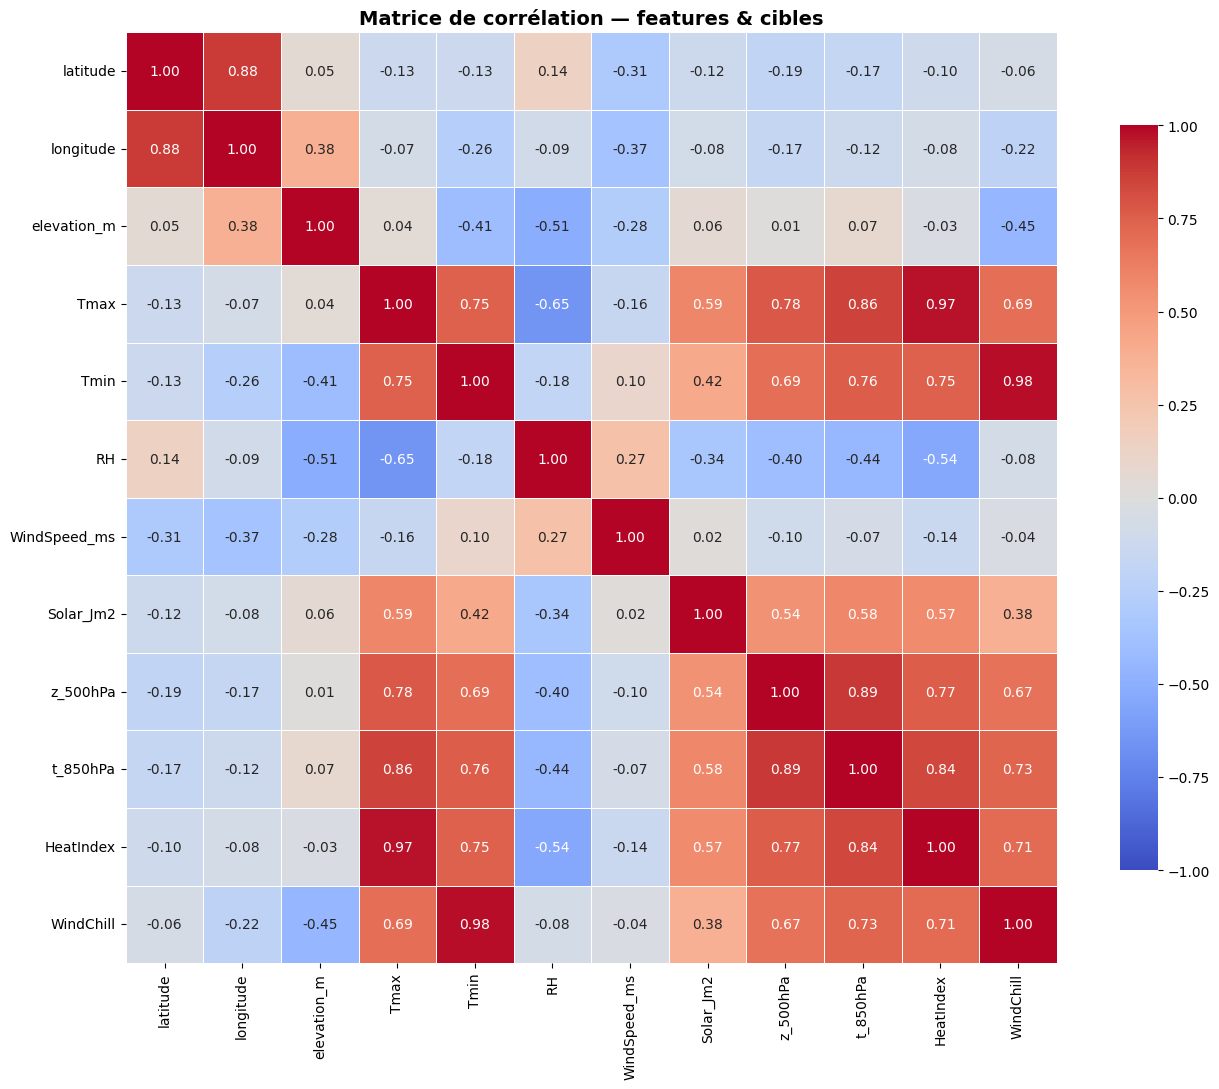

Paires |r| > 0.9 (redondance potentielle):
       WindChill ~ Tmin           r=+0.977
       HeatIndex ~ Tmax           r=+0.973

Top |r| avec HeatIndex:
Tmax         0.973
t_850hPa     0.843
z_500hPa     0.765
Tmin         0.748
Solar_Jm2    0.569

Top |r| avec WindChill:
Tmin           0.977
t_850hPa       0.732
Tmax           0.691
z_500hPa       0.673
elevation_m   -0.453


In [123]:
# ── Heatmap de corrélation complète (features + cibles) ──
corr_cols = FEATURES + TARGETS
corr = data[corr_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matrice de corrélation — features & cibles", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# Paires fortement colinéaires (|r| > 0.9, hors diagonale) -> redondance / fuite potentielle
keep = np.tril(np.ones_like(corr, dtype=bool), k=-1)
pairs = corr.where(keep).abs().stack().sort_values(ascending=False)
pairs = pairs[pairs > 0.9]
print("Paires |r| > 0.9 (redondance potentielle):")
for (a, b), _ in pairs.items():
    print(f"  {a:>14s} ~ {b:<14s} r={corr.loc[a, b]:+.3f}")

# Top corrélations (|r|) de chaque cible avec les features
for t in TARGETS:
    order = corr[t].drop(TARGETS).abs().sort_values(ascending=False).head(5).index
    print(f"\nTop |r| avec {t}:")
    print(corr.loc[order, t].round(3).to_string())

## 3. Split chronologique par station — 70 / 15 / 15
On découpe **chaque station** dans l'ordre temporel : 70 % d'abord (train),
puis 15 % (val), puis 15 % (test). Ce choix de senior évite la fuite de données
— pas de mélange aléatoire, pas de chevauchement de stations entre les jeux,
et chaque jeu reste contigu dans le temps.

In [124]:
def split_station(g):
    g = g.sort_values("date")
    n = len(g)
    i_tr = int(n * TRAIN_RATIO)
    i_va = int(n * (TRAIN_RATIO + VAL_RATIO))
    return g.iloc[:i_tr], g.iloc[i_tr:i_va], g.iloc[i_va:]

parts = [split_station(g) for _, g in data.groupby("station")]
train_df = pd.concat([p[0] for p in parts], ignore_index=True)
val_df   = pd.concat([p[1] for p in parts], ignore_index=True)
test_df  = pd.concat([p[2] for p in parts], ignore_index=True)

tot = len(data)
for name, d in [("train",train_df),("val",val_df),("test",test_df)]:
    print(f"{name:5s}: {len(d):7d} rows ({len(d)/tot*100:4.1f}%)  "
          f"{d['date'].min().date()} -> {d['date'].max().date()}")

train:  216231 rows (70.0%)  2000-01-01 -> 2020-04-16
val  :   46356 rows (15.0%)  2014-09-13 -> 2023-08-23
test :   46356 rows (15.0%)  2017-11-07 -> 2025-12-31


## 4. Normalisation Min-Max (fit sur TRAIN uniquement)
`MinMaxScaler` sur les features et sur les cibles, ajusté **seulement** sur le
train (pas de fuite). Le scaler des cibles est conservé pour l'inverse-transform.

In [125]:
scaler_X = MinMaxScaler().fit(train_df[FEATURES])
scaler_y = MinMaxScaler().fit(train_df[TARGETS])

def scale(df):
    df = df.copy()
    df[FEATURES] = scaler_X.transform(df[FEATURES])
    df[TARGETS]  = scaler_y.transform(df[TARGETS])
    return df

train_n, val_n, test_n = scale(train_df), scale(val_df), scale(test_df)
print("features range (train, post-scale):",
      float(train_n[FEATURES].min().min()), "->", float(train_n[FEATURES].max().max()))
print("targets data_min_ :", dict(zip(TARGETS, np.round(scaler_y.data_min_, 2))))
print("targets data_max_ :", dict(zip(TARGETS, np.round(scaler_y.data_max_, 2))))

features range (train, post-scale): 0.0 -> 1.0000000000000002
targets data_min_ : {'HeatIndex': np.float64(-5.48), 'WindChill': np.float64(-18.94)}
targets data_max_ : {'HeatIndex': np.float64(77.44), 'WindChill': np.float64(27.78)}


## 5. Windowing — per-station sliding sequences
Windows never cross a station boundary. X = INPUT_WINDOW days of features; y = next OUTPUT_WINDOW days of targets.

In [126]:
def make_sequences(df_norm):
    Xs, Ys = [], []
    win = INPUT_WINDOW + OUTPUT_WINDOW
    for _, g in df_norm.groupby("station"):
        g = g.sort_values("date")
        F = g[FEATURES].to_numpy(np.float32)
        T = g[TARGETS].to_numpy(np.float32)
        for i in range(len(g) - win + 1):
            Xs.append(F[i:i+INPUT_WINDOW])
            Ys.append(T[i+INPUT_WINDOW:i+win])
    if not Xs:
        return (np.empty((0,INPUT_WINDOW,len(FEATURES)),np.float32),
                np.empty((0,OUTPUT_WINDOW,len(TARGETS)),np.float32))
    return np.stack(Xs), np.stack(Ys)

X_tr, y_tr = make_sequences(train_n)
X_va, y_va = make_sequences(val_n)
X_te, y_te = make_sequences(test_n)
print("X_train:", X_tr.shape, "y_train:", y_tr.shape)
print("X_val  :", X_va.shape, "X_test:", X_te.shape)

X_train: (215841, 7, 10) y_train: (215841, 7, 2)
X_val  : (45966, 7, 10) X_test: (45966, 7, 10)


## 6. Modèles temporels Keras — LSTM · GRU · TCN · BiLSTM · TFT
Cinq architectures partageant la même interface `(INPUT_WINDOW, n_features) -> (OUTPUT_WINDOW, n_targets)`, donc directement comparables. RNN empilés (`N_LAYERS`) ; **BiLSTM** encode la fenêtre dans les deux sens ; **TCN** = convolutions 1D causales dilatées (non-récurrent) ; **TFT** = Temporal Fusion Transformer compact (GRN + encodeur LSTM + self-attention multi-tête).

In [127]:
def _grn(x, units, dropout=DROPOUT):
    """Gated Residual Network (Lim et al., 2021) — brique de base du TFT.
    Projection ELU -> gating GLU -> connexion résiduelle -> LayerNorm."""
    residual = x if x.shape[-1] == units else layers.Dense(units)(x)
    h = layers.Dense(units, activation="elu")(x)
    h = layers.Dense(units)(h)
    h = layers.Dropout(dropout)(h)
    gate = layers.Dense(units, activation="sigmoid")(h)   # GLU
    h = layers.Multiply()([h, gate])
    return layers.LayerNormalization()(layers.Add()([residual, h]))


def build_model(name):
    """Construit & compile un modèle Keras à partir de la config centrale."""
    nf, nt = len(FEATURES), len(TARGETS)
    inp = keras.Input(shape=(INPUT_WINDOW, nf))

    if name in ("LSTM", "GRU"):
        RNN = layers.LSTM if name == "LSTM" else layers.GRU
        x = inp
        for li in range(N_LAYERS):
            x = RNN(HIDDEN, return_sequences=(li < N_LAYERS - 1))(x)
            x = layers.Dropout(DROPOUT)(x)
    elif name == "BiLSTM":
        x = inp
        for li in range(N_LAYERS):                 # LSTM bidirectionnel (encodeur)
            x = layers.Bidirectional(
                layers.LSTM(HIDDEN, return_sequences=(li < N_LAYERS - 1)))(x)
            x = layers.Dropout(DROPOUT)(x)
    elif name == "TCN":
        x = inp
        for d in (1, 2, 4):                         # convolutions causales dilatées
            x = layers.Conv1D(HIDDEN, 3, padding="causal", dilation_rate=d,
                              activation="relu")(x)
            x = layers.Dropout(DROPOUT)(x)
        x = x[:, -1, :]                             # dernier pas de temps
    elif name == "TFT":
        # Temporal Fusion Transformer (version compacte) : embedding par variable
        # via GRN -> encodeur LSTM -> self-attention multi-tête interprétable -> GRN.
        u = HIDDEN
        x = layers.Dense(u)(inp)                    # embedding des variables
        x = _grn(x, u)                              # variable selection / processing
        x = layers.LSTM(u, return_sequences=True)(x)  # traitement local séquentiel
        x = _grn(x, u)                              # enrichissement
        attn = layers.MultiHeadAttention(num_heads=4, key_dim=max(1, u // 4))(x, x)
        x = layers.LayerNormalization()(layers.Add()([x, layers.Dropout(DROPOUT)(attn)]))
        x = _grn(x, u)                              # feed-forward position-wise
        x = x[:, -1, :]                             # contexte final
    else:
        raise ValueError(f"modèle inconnu: {name}")

    x = layers.Dense(OUTPUT_WINDOW * nt)(x)
    out = layers.Reshape((OUTPUT_WINDOW, nt))(x)
    m = keras.Model(inp, out, name=name)
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="mse", metrics=["mae"])
    return m

MODEL_NAMES = ["LSTM", "GRU", "TCN", "BiLSTM", "TFT"]
for nm in MODEL_NAMES:
    print(f"{nm:12s} | params: {build_model(nm).count_params()/1e6:.3f} M")

LSTM         | params: 0.336 M
GRU          | params: 0.254 M
TCN          | params: 0.104 M
BiLSTM       | params: 0.934 M
TFT          | params: 0.350 M


## 7. Benchmark — entraînement multi-modèles
Boucle identique pour chaque modèle : `model.fit` avec early stopping et
réduction du learning rate sur la validation.

In [128]:
CKPT_DIR   = ART_DIR / "checkpoints"; CKPT_DIR.mkdir(exist_ok=True)
MODELS_DIR = ART_DIR / "models";      MODELS_DIR.mkdir(exist_ok=True)

def train_keras(name, epochs=EPOCHS):
    m = build_model(name)
    cbs = [
        EarlyStopping(monitor="val_loss", patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=max(2, PATIENCE // 2), min_lr=1e-6, verbose=0),
        # Reprise après coupure : sauve l'état COMPLET (poids + optimiseur + epoch)
        # à chaque epoch et reprend automatiquement là où on s'est arrêté au redémarrage.
        keras.callbacks.BackupAndRestore(backup_dir=str(CKPT_DIR / f"backup_{name}")),
        # Meilleur checkpoint par modèle (selon val_loss)
        keras.callbacks.ModelCheckpoint(str(CKPT_DIR / f"{name}_best.keras"),
                                        monitor="val_loss", save_best_only=True, verbose=0),
        # Historique persistant (append -> survit aux coupures)
        keras.callbacks.CSVLogger(str(CKPT_DIR / f"{name}_history.csv"), append=True),
    ]
    h = m.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=epochs,
              batch_size=BATCH_SIZE, callbacks=cbs, verbose=1)
    return m, h.history

def inv_y(arr):                                  # [N, OUT, n_targets] scaled -> physical
    N, O, T = arr.shape
    return scaler_y.inverse_transform(arr.reshape(-1, T)).reshape(N, O, T)

def eval_metrics(p, t):                          # p, t in physical units
    rmse = np.sqrt(((p - t) ** 2).mean(axis=0))  # [OUT, n_targets]
    mae  = np.abs(p - t).mean(axis=0)
    r2 = np.array([r2_score(t[..., j].ravel(), p[..., j].ravel())
                   for j in range(t.shape[-1])])
    return rmse, mae, r2

true = inv_y(y_te)
results, histories = {}, {}
for name in MODEL_NAMES:
    print(f"\n===== {name} =====")
    m, hist = train_keras(name)
    m.save(str(MODELS_DIR / f"{name}.keras"))    # on sauvegarde CHAQUE modèle entraîné
    pred = inv_y(m.predict(X_te, verbose=0))
    rmse, mae, r2 = eval_metrics(pred, true)
    results[name] = {"model": m, "pred": pred, "rmse": rmse, "mae": mae, "r2": r2,
                     "n_params": m.count_params()}
    histories[name] = hist

# Meilleur modèle (RMSE moyen sur le test) -> exposé pour les cellules suivantes
best_name = min(results, key=lambda k: results[k]["rmse"].mean())
model, pred = results[best_name]["model"], results[best_name]["pred"]
print(f"\nMeilleur modèle (RMSE moyen test): {best_name}")


===== LSTM =====
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 77s 83ms/step - loss: 0.0201 - mae: 0.0957 - val_loss: 0.0034 - val_mae: 0.0444 - learning_rate: 0.0010
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - loss: 0.0047 - mae: 0.0528 - val_loss: 0.0029 - val_mae: 0.0405 - learning_rate: 0.0010
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 71s 85ms/step - loss: 0.0038 - mae: 0.0475 - val_loss: 0.0028 - val_mae: 0.0394 - learning_rate: 0.0010
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 70s 83ms/step - loss: 0.0034 - mae: 0.0447 - val_loss: 0.0028 - val_mae: 0.0397 - learning_rate: 0.0010
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 73s 86ms/step - loss: 0.0032 - mae: 0.0431 - val_loss: 0.0027 - val_mae: 0.0385 - learning_rate: 0.0010

===== GRU =====
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 86ms/step - loss: 0.0184 - mae: 0.0930 - val_loss: 0.0030 - val_mae: 0.0414 - learning_rate: 0.0010
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 93ms/step - loss: 0.0045 - mae: 0.0516 - val_loss: 0.0028 - val_

KeyboardInterrupt: 

KeyError: 'TCN'

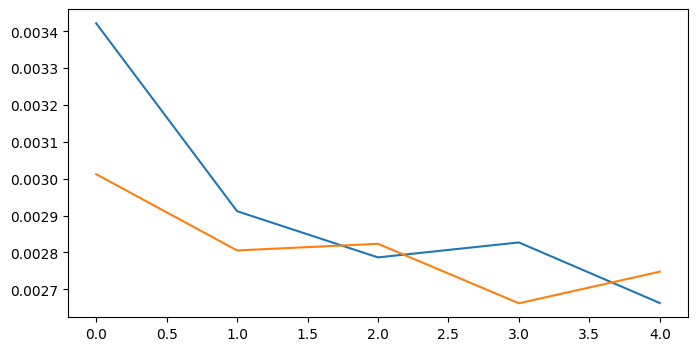

In [129]:
# Courbes d'apprentissage (validation) — tous les modèles
plt.figure(figsize=(8, 4))
for name in MODEL_NAMES:
    plt.plot(histories[name]["val_loss"], label=f"{name} (val)")
plt.xlabel("epoch"); plt.ylabel("MSE (normalisé)")
plt.title("Courbes d'apprentissage — comparaison"); plt.legend(); plt.grid(alpha=.3); plt.show()

## 7bis. Comparaison des modèles
Tableau récapitulatif (RMSE / MAE / R² par cible, en unités physiques sur le jeu
de test) et comparaison visuelle du RMSE.

In [ ]:
# ── Tableau comparatif ──
rows = []
for name in MODEL_NAMES:
    r = results[name]
    row = {"modèle": name, "params(M)": round(r["n_params"] / 1e6, 3)}
    for j, t in enumerate(TARGETS):
        row[f"RMSE_{t}"] = round(float(r["rmse"][:, j].mean()), 3)
        row[f"MAE_{t}"]  = round(float(r["mae"][:, j].mean()), 3)
        row[f"R2_{t}"]   = round(float(r["r2"][j]), 3)
    rows.append(row)
bench_df = pd.DataFrame(rows).set_index("modèle")
print(bench_df.to_string())
bench_df

             params(M)  RMSE_HeatIndex  MAE_HeatIndex  R2_HeatIndex  RMSE_WindChill  MAE_WindChill  R2_WindChill
modèle                                                                                                          
LSTM             0.336           3.724          2.716         0.816           2.332          1.817         0.881
GRU              0.254           3.707          2.712         0.817           2.307          1.801         0.882
TCN              0.104           3.731          2.761         0.816           2.411          1.902         0.873
StackedLSTM      0.134           3.873          2.842         0.802           2.408          1.883         0.874


,params(M),RMSE_HeatIndex,MAE_HeatIndex,R2_HeatIndex,RMSE_WindChill,MAE_WindChill,R2_WindChill
modèle,,,,,,,
LSTM,0.336,3.724,2.716,0.816,2.332,1.817,0.881
GRU,0.254,3.707,2.712,0.817,2.307,1.801,0.882
TCN,0.104,3.731,2.761,0.816,2.411,1.902,0.873
StackedLSTM,0.134,3.873,2.842,0.802,2.408,1.883,0.874


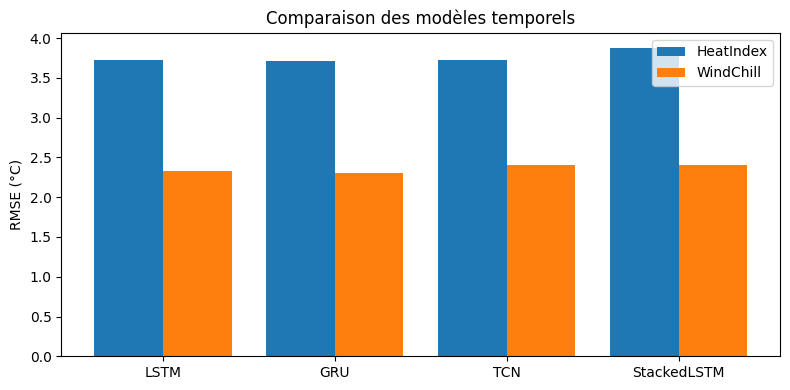

In [ ]:
# ── Comparaison visuelle : RMSE moyen par modèle & cible ──
x = np.arange(len(MODEL_NAMES)); w = 0.8 / len(TARGETS)
fig, ax = plt.subplots(figsize=(8, 4))
for k, t in enumerate(TARGETS):
    vals = [results[n]["rmse"][:, k].mean() for n in MODEL_NAMES]
    ax.bar(x + (k - (len(TARGETS) - 1) / 2) * w, vals, w, label=t)
ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES)
ax.set_ylabel("RMSE (°C)"); ax.set_title("Comparaison des modèles temporels")
ax.legend(); plt.tight_layout(); plt.show()

## 7ter. Métriques par horizon de prévision
RMSE et MAE en fonction de l'horizon `J+1 … J+OUTPUT_WINDOW` (le barchart ci-dessus
ne montre que la moyenne sur les horizons). L'erreur croît normalement avec
l'horizon : prévoir J+7 est plus dur que J+1.

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

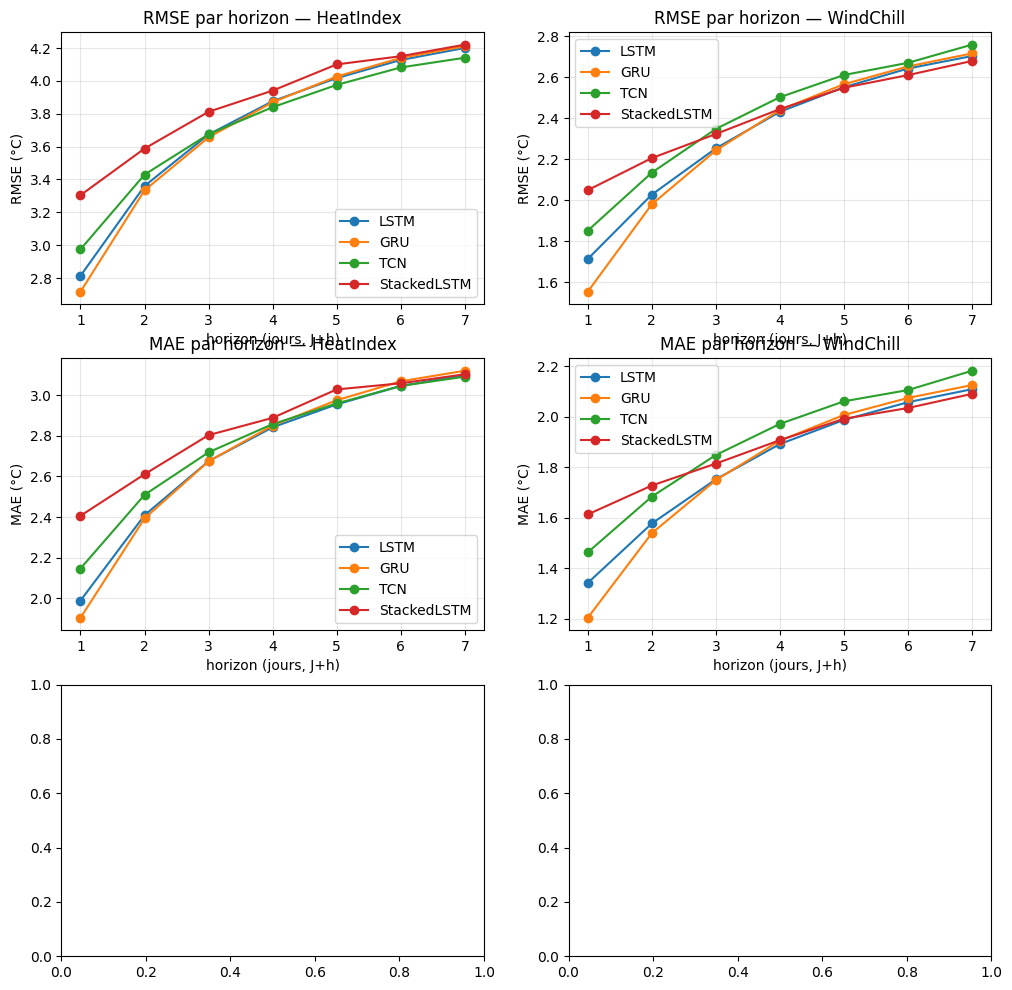

In [ ]:
# ── RMSE & MAE par horizon (J+1 ... J+H), une courbe par modèle ──
H = OUTPUT_WINDOW
horizons = np.arange(1, H + 1)
panels = [("RMSE", "rmse"), ("MAE", "mae"), ("R²", "r2")]
fig, axes = plt.subplots(len(panels), len(TARGETS),
                         figsize=(6 * len(TARGETS), 4 * len(panels)), squeeze=False)
for r, (label, key) in enumerate(panels):
    for j, t in enumerate(TARGETS):
        ax = axes[r, j]
        for name in MODEL_NAMES:
            ax.plot(horizons, results[name][key][:, j], marker="o", label=name)
        ax.set_title(f"{label} par horizon — {t}")
        ax.set_xlabel("horizon (jours, J+h)"); ax.set_ylabel(f"{label} (°C)")
        ax.set_xticks(horizons); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

## 8. Prédictions vs réel (meilleur modèle)

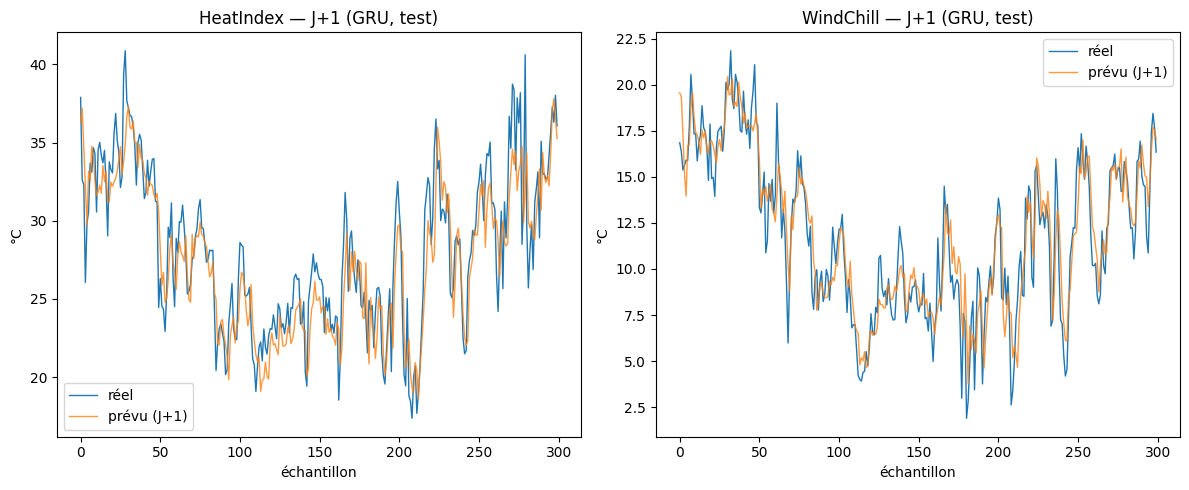

In [ ]:
# Prévisions J+1 vs réel pour le meilleur modèle (début du jeu de test)
plt.figure(figsize=(12, 5))
for j, t in enumerate(TARGETS):
    plt.subplot(1, 2, j + 1)
    n = min(300, pred.shape[0])
    plt.plot(true[:n, 0, j], label="réel", lw=1)
    plt.plot(pred[:n, 0, j], label="prévu (J+1)", lw=1, alpha=0.8)
    plt.title(f"{t} — J+1 ({best_name}, test)"); plt.legend()
    plt.xlabel("échantillon"); plt.ylabel("°C")
plt.tight_layout(); plt.show()

## 9. Save artifacts

In [ ]:
# NB : tous les modèles ont déjà été sauvegardés dans ART_DIR/models/ pendant le benchmark,
# et les checkpoints de reprise sont dans ART_DIR/checkpoints/.
best = results[best_name]["model"]
best.save(str(ART_DIR / "lstm_nasa_power.keras"))          # alias pratique du MEILLEUR modèle
joblib.dump(scaler_X, ART_DIR / "scaler_X.pkl")            # scalers Min-Max (fit train)
joblib.dump(scaler_y, ART_DIR / "scaler_y.pkl")
bench_df.to_csv(ART_DIR / "benchmark_metrics.csv")         # tableau comparatif

meta = {
    "framework": "tensorflow", "best_model": best_name,
    "models": {name: {"path": f"models/{name}.keras",
                      "rmse_mean": round(float(results[name]["rmse"].mean()), 3),
                      "params": int(results[name]["n_params"])}
               for name in MODEL_NAMES},
    "features": FEATURES, "targets": TARGETS,
    "scaler": "minmax", "feature_range": [0, 1],
    "split": {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO,
              "scheme": "per-station chronological"},
    "input_window": INPUT_WINDOW, "output_window": OUTPUT_WINDOW,
    "hidden": HIDDEN, "n_layers": N_LAYERS,
}
json.dump(meta, open(ART_DIR / "lstm_meta.json", "w"), indent=2)
print("Tous les modèles sauvegardés ->", MODELS_DIR, "(", ", ".join(MODEL_NAMES), ")")
print("meilleur alias:", ART_DIR / "lstm_nasa_power.keras",
      "| scalers | benchmark_metrics.csv | lstm_meta.json")

saved -> artifacts/lstm_nasa_power.keras | scaler_X.pkl, scaler_y.pkl | benchmark_metrics.csv | lstm_meta.json
